# Phase 1 — Data Exploration
**AAI-511 · Composer Identification via Deep Learning**

File counts per composer across train/dev/test splits, average MIDI duration per composer, and MIDI file validation.

In [1]:
# Import libraries
import os
import pretty_midi
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


In [2]:
# 1. File Counts per Composer
DATA_DIR = 'data'
COMPOSERS = ['bach', 'beethoven', 'chopin', 'mozart']
splits = ['train', 'dev', 'test']
records = []

for split in splits:
    split_dir = os.path.join(DATA_DIR, split)
    for composer in sorted(os.listdir(split_dir)):
        if composer not in COMPOSERS:
            continue
        composer_dir = os.path.join(split_dir, composer)
        if not os.path.isdir(composer_dir):
            continue
        files = [f for f in os.listdir(composer_dir) if f.endswith('.mid')]
        records.append({'split': split, 'composer': composer.capitalize(), 'count': len(files)})

df = pd.DataFrame(records)
pivot = df.pivot(index='composer', columns='split', values='count').fillna(0).astype(int)
pivot['total'] = pivot.sum(axis=1)
pivot = pivot[['train', 'dev', 'test', 'total']]
print(pivot.to_string())

split      train  dev  test  total
composer                          
Bach          42    4     4     50
Beethoven     42    4     4     50
Chopin        41    4     4     49
Mozart        41    4     4     49


In [3]:
# 2. Average Duration per Composer (train set)
duration_records = []

for composer in sorted(os.listdir(os.path.join(DATA_DIR, 'train'))):
    if composer not in COMPOSERS:
        continue
    composer_dir = os.path.join(DATA_DIR, 'train', composer)
    if not os.path.isdir(composer_dir):
        continue
    for fname in os.listdir(composer_dir):
        if not fname.endswith('.mid'):
            continue
        fpath = os.path.join(composer_dir, fname)
        try:
            midi = pretty_midi.PrettyMIDI(fpath)
            duration_records.append({'composer': composer.capitalize(), 'duration_s': midi.get_end_time()})
        except Exception:
            pass

df_dur = pd.DataFrame(duration_records)
summary = df_dur.groupby('composer')['duration_s'].agg(
    mean='mean', median='median', min='min', max='max', files='count'
).round(1)
summary['mean_min'] = (summary['mean'] / 60).round(2)
print(summary[['files', 'mean', 'mean_min', 'median', 'min', 'max']].to_string())

/Users/mgarzon/Desktop/USD/AAI511/Assigments/Assignment2/.venv/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


           files   mean  mean_min  median   min     max
composer                                               
Bach          42  280.4      4.67   117.9  61.7  1047.9
Beethoven     42  251.7      4.19   162.4  27.0   819.8
Chopin        41  274.8      4.58   189.0  40.9  2130.7
Mozart        41  503.4      8.39   466.9  95.0  1633.0


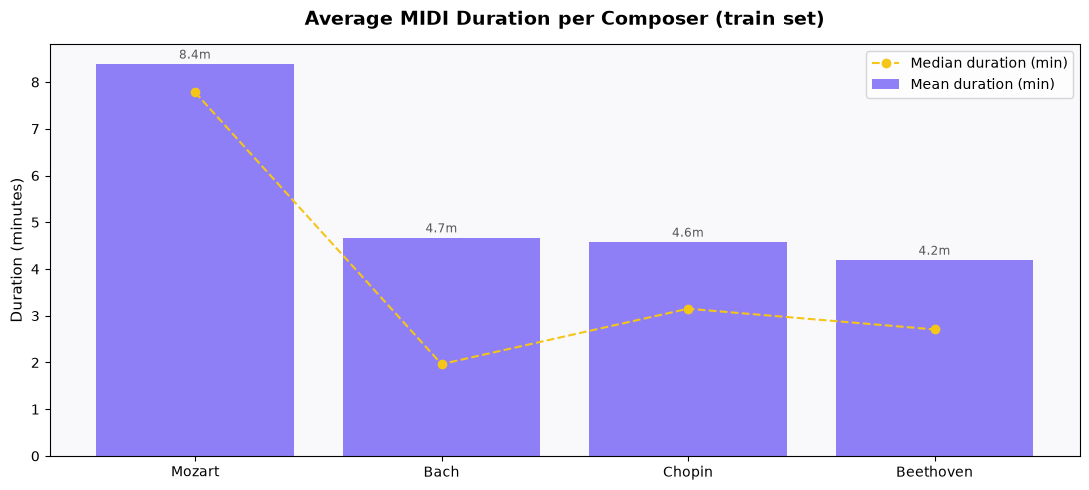

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

order = summary['mean'].sort_values(ascending=False).index.tolist()
means = summary.loc[order, 'mean'] / 60
medians = summary.loc[order, 'median'] / 60

ax.bar(order, means, color='#7c6af7', alpha=0.85, label='Mean duration (min)')
ax.plot(order, medians, 'o--', color='#f5c518', linewidth=1.5, markersize=6, label='Median duration (min)')

for i, (comp, val) in enumerate(zip(order, means)):
    ax.text(i, val + 0.05, f'{val:.1f}m', ha='center', va='bottom', fontsize=8.5, color='#555')

ax.set_ylabel('Duration (minutes)', fontsize=11)
ax.set_title('Average MIDI Duration per Composer (train set)', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10)
ax.set_facecolor('#f9f9fb')
fig.tight_layout()
plt.show()

In [5]:
# 3. Summary
total_files = pivot['total'].sum()
total_composers = len(pivot)
overall_avg = df_dur['duration_s'].mean() / 60

print(f"Composers   : {total_composers}")
print(f"Total files : {total_files}")
print(f"Avg duration: {overall_avg:.2f} minutes")
print(f"Split ratio : train={pivot['train'].sum()} | dev={pivot['dev'].sum()} | test={pivot['test'].sum()}")

Composers   : 4
Total files : 198
Avg duration: 5.45 minutes
Split ratio : train=166 | dev=16 | test=16


In [6]:
# 4. Corrupt MIDI Files
corrupt = []
valid = []

for split in ['train', 'dev', 'test']:
    split_dir = os.path.join(DATA_DIR, split)
    for composer in sorted(os.listdir(split_dir)):
        if composer not in COMPOSERS:
            continue
        composer_dir = os.path.join(split_dir, composer)
        if not os.path.isdir(composer_dir):
            continue
        for fname in os.listdir(composer_dir):
            if not fname.endswith('.mid'):
                continue
            fpath = os.path.join(composer_dir, fname)
            try:
                pretty_midi.PrettyMIDI(fpath)
                valid.append(fpath)
            except Exception as e:
                corrupt.append({'file': fpath, 'error': str(e)})

print(f"Valid   : {len(valid)}")
print(f"Corrupt : {len(corrupt)}")

if corrupt:
    print("\nCorrupted files:")
    for c in corrupt:
        print(f"  {c['file']} — {c['error']}")
else:
    print("\nAll MIDI files are readable.")

/Users/mgarzon/Desktop/USD/AAI511/Assigments/Assignment2/.venv/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Valid   : 198
Corrupt : 0

All MIDI files are readable.


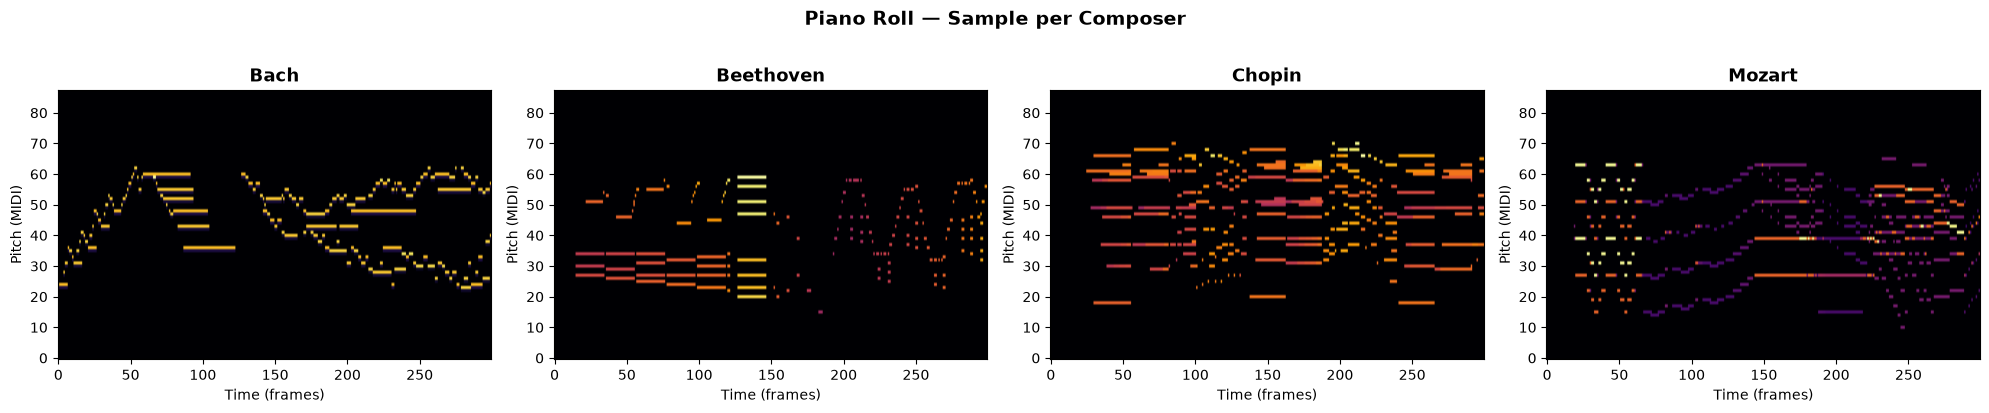

In [7]:
# 5. Piano Roll Visualization
composers_sample = COMPOSERS  # ['bach', 'beethoven', 'chopin', 'mozart']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, composer in zip(axes, composers_sample):
    folder = os.path.join(DATA_DIR, 'train', composer)
    midi_file = sorted(f for f in os.listdir(folder) if f.endswith('.mid'))[0]
    midi = pretty_midi.PrettyMIDI(os.path.join(folder, midi_file))
    roll = midi.get_piano_roll(fs=10)  # 10 frames per second
    roll = roll[21:109, :300]          # MIDI notes 21-108 (piano range), first 30s
    ax.imshow(roll, aspect='auto', origin='lower', cmap='inferno')
    ax.set_title(composer.capitalize(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (frames)')
    ax.set_ylabel('Pitch (MIDI)')

fig.suptitle('Piano Roll — Sample per Composer', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()